# Clothing Image Classification with a Compact CNN

A reproducible, portfolio-ready PyTorch workflow for five clothing classes.

## 1. Imports, Seed, GPU und Mixed Precision

Diese Zelle bereitet Python, PyTorch und die Hardware für das Training vor.

In [1]:
# Erklärung: Importiert Path, damit Dateipfade sauber und plattformunabhängig gebaut werden können.
from pathlib import Path
import os
# Erklärung: Importiert random für Zufallsoperationen und Seed-Kontrolle.
import random
# Erklärung: Importiert copy, damit wir den besten Modellzustand später tief kopieren können.
import copy
# Erklärung: Importiert Counter, um Klassenhäufigkeiten im Trainingsset zu zählen.
from collections import Counter

# Erklärung: Importiert NumPy für numerische Operationen und Seed-Kontrolle.
import numpy as np
# Erklärung: Importiert Matplotlib zum Zeichnen von Bildern, Kurven und Matrizen.
import matplotlib.pyplot as plt

# Erklärung: Importiert PyTorch als Hauptbibliothek für Deep Learning.
import torch
# Erklärung: Importiert neuronale Netzwerkbausteine wie Conv2d, Linear und Loss-Funktionen.
import torch.nn as nn
# Erklärung: Importiert DataLoader für Batches und WeightedRandomSampler für ausgewogeneres Sampling.
from torch.utils.data import DataLoader, WeightedRandomSampler
# Erklärung: Importiert ImageFolder und Transformationsfunktionen für Bilddatensätze.
from torchvision import datasets, transforms

# Erklärung: Legt einen festen Seed fest, damit Runs besser reproduzierbar sind.
SEED = 42
# Erklärung: Setzt den Seed für diese Bibliothek, damit Zufall möglichst kontrolliert ist.
random.seed(SEED)
# Erklärung: Setzt den Seed für diese Bibliothek, damit Zufall möglichst kontrolliert ist.
np.random.seed(SEED)
# Erklärung: Setzt den Seed für diese Bibliothek, damit Zufall möglichst kontrolliert ist.
torch.manual_seed(SEED)
# Erklärung: Setzt den Seed für diese Bibliothek, damit Zufall möglichst kontrolliert ist.
torch.cuda.manual_seed_all(SEED)
# Erklärung: Erlaubt cuDNN, schnelle Algorithmen für feste Bildgrößen zu wählen.
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# Erklärung: Wählt automatisch GPU (cuda), falls verfügbar, sonst CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Erklärung: Aktiviert Mixed Precision, wenn eine CUDA-GPU vorhanden ist.
USE_AMP = torch.cuda.is_available()

# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Device:", device)
# Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
if torch.cuda.is_available():
    # Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. WandB-Konfiguration

Diese Zelle verbindet den Run mit Weights & Biases, damit Training und Ergebnisse online gespeichert werden.

In [2]:
# Weights & Biases is optional for local and portfolio use.
USE_WANDB = os.getenv("USE_WANDB", "0") == "1"
WANDB_ENTITY = os.getenv("WANDB_ENTITY", "eidl-thm")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "clothing-image-classification")
WANDB_RUN_NAME = os.getenv("WANDB_RUN_NAME", "compact-cnn-weighted-sampler")
WANDB_GROUP = os.getenv("WANDB_GROUP", "portfolio")

if USE_WANDB:
    try:
        import wandb
    except ImportError as exc:
        raise ImportError("Install wandb or set USE_WANDB=0.") from exc
    wandb.login()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from [local-user]\_netrc.
wandb: Currently logged in as: [redacted] ([redacted]) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 3. Dataset-Pfade und Grundeinstellungen

Diese Zelle sagt dem Notebook, wo der Datensatz liegt und mit welchen Grundparametern trainiert wird.

In [3]:
# Resolve paths relative to the repository instead of a personal computer.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = Path(
    os.getenv(
        "CLOTHING_DATA_DIR",
        PROJECT_ROOT / "data" / "clothing_clean_5classes_split_audit_copy",
    )
).expanduser().resolve()
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not split_dir.is_dir():
        raise FileNotFoundError(
            f"Missing dataset split: {split_dir}. Run scripts/prepare_dataset.py first."
        )

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH = MODEL_DIR / "best_clothing_cnn_final.pt"

classes = sorted(path.name for path in TRAIN_DIR.iterdir() if path.is_dir())
num_classes = len(classes)
if num_classes != 5:
    raise ValueError(f"Expected 5 classes, found {num_classes}: {classes}")

print("Dataset:", DATA_DIR)
print("Classes:", classes)
print("Number of classes:", num_classes)


Dataset: data/clothing_clean_5classes_split_audit_copy
Classes: ['long-sleeved', 'pants', 'shorts', 'socks', 't-shirt']
Number of classes: 5


## 4. Klassenverteilung zählen

Diese Zelle zählt Bilder pro Klasse und pro Split. Das ist Teil der Datensatzanalyse.

In [4]:
# Erklärung: Definiert eine Hilfsfunktion, die Bilder pro Klasse in einem Split zählt.
def count_split(split_dir):
    # Erklärung: Erzeugt eine leere Liste, in der die Zählergebnisse gesammelt werden.
    rows = []
    # Erklärung: Geht alle Klassenordner eines Splits sortiert durch.
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        # Erklärung: Geht alle Klassenordner eines Splits sortiert durch.
        n = len([p for p in class_dir.iterdir() if p.is_file()])
        # Erklärung: Speichert Klassenname und Bildanzahl als Tupel.
        rows.append((class_dir.name, n))
    # Erklärung: Gibt die gesammelten Zählergebnisse zurück.
    return rows

# Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    rows = count_split(split_dir)
    # Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
    print(f"\n{split_name.upper()}")
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    for cls, n in rows:
        # Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
        print(f"{cls:12s}: {n}")
    # Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
    print(f"Total       : {sum(n for _, n in rows)}")



TRAIN
long-sleeved: 625
pants       : 758
shorts      : 496
socks       : 623
t-shirt     : 900
Total       : 3402

VAL
long-sleeved: 77
pants       : 90
shorts      : 59
socks       : 76
t-shirt     : 110
Total       : 412

TEST
long-sleeved: 70
pants       : 90
shorts      : 57
socks       : 77
t-shirt     : 110
Total       : 404


## 5. Preprocessing, Augmentation, Dataset und DataLoader

Diese Zelle definiert, wie Bilder geladen, transformiert und in Batches an das Modell gegeben werden.

In [5]:
# Erklärung: Mean-Werte des Trainingsdatensatzes für RGB-Kanäle.
mean = [0.5065, 0.4740, 0.4509]
# Erklärung: Standardabweichungen des Trainingsdatensatzes für RGB-Kanäle.
std = [0.2158, 0.2072, 0.2007]

# Erklärung: Definiert die Transformationen, die nur auf Trainingsbilder angewendet werden.
train_transform = transforms.Compose([
    # Erklärung: Skaliert jedes Bild auf die feste Eingabegröße des CNN.
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    # Erklärung: Spiegelt Trainingsbilder zufällig horizontal, um mehr Variation zu erzeugen.
    transforms.RandomHorizontalFlip(p=0.5),
    # Erklärung: Dreht Trainingsbilder leicht, damit das Modell robuster wird.
    transforms.RandomRotation(degrees=6),
    # Erklärung: Verändert Helligkeit, Kontrast und Sättigung leicht für robustere Features.
    transforms.ColorJitter(brightness=0.06, contrast=0.06, saturation=0.06),
    # Erklärung: Wandelt PIL-Bilder in PyTorch-Tensoren um.
    transforms.ToTensor(),
    # Erklärung: Normalisiert die Pixelwerte mit Mean und Std des Datensatzes.
    transforms.Normalize(mean, std),
])

# Erklärung: Definiert Transformationen für Validation/Test ohne zufällige Augmentation.
val_test_transform = transforms.Compose([
    # Erklärung: Skaliert jedes Bild auf die feste Eingabegröße des CNN.
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    # Erklärung: Wandelt PIL-Bilder in PyTorch-Tensoren um.
    transforms.ToTensor(),
    # Erklärung: Normalisiert die Pixelwerte mit Mean und Std des Datensatzes.
    transforms.Normalize(mean, std),
])

# Erklärung: Lädt Bilder automatisch anhand der Ordnerstruktur als klassifizierten Datensatz.
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
# Erklärung: Lädt Bilder automatisch anhand der Ordnerstruktur als klassifizierten Datensatz.
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)
# Erklärung: Lädt Bilder automatisch anhand der Ordnerstruktur als klassifizierten Datensatz.
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

# Erklärung: Sammelt alle Klassenlabels aus dem Trainingsdatensatz.
train_targets = [label for _, label in train_dataset.samples]
# Erklärung: Zählt, wie oft jede Klasse im Trainingsset vorkommt.
train_counts = Counter(train_targets)
# Erklärung: Berechnet pro Bild ein Gewicht; seltenere Klassen bekommen höhere Wahrscheinlichkeit.
sample_weights = torch.DoubleTensor([1.0 / train_counts[label] for label in train_targets])
# Erklärung: Erstellt einen Sampler, der Trainingsbilder ausgewogener zieht.
train_sampler = WeightedRandomSampler(
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    weights=sample_weights,
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    num_samples=len(sample_weights),
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    replacement=True,
)

# Erklärung: Erstellt einen DataLoader, der Bilder in Batches liefert.
train_loader = DataLoader(
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    train_dataset,
    # Erklärung: Übergibt die Batchgröße an den DataLoader.
    batch_size=BATCH_SIZE,
    # Erklärung: Übergibt den WeightedRandomSampler an den Trainings-DataLoader.
    sampler=train_sampler,
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    num_workers=NUM_WORKERS,
    # Erklärung: Beschleunigt den Transfer zur GPU, wenn CUDA verfügbar ist.
    pin_memory=torch.cuda.is_available(),
)
# Erklärung: Erstellt einen DataLoader, der Bilder in Batches liefert.
val_loader = DataLoader(
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    val_dataset,
    # Erklärung: Übergibt die Batchgröße an den DataLoader.
    batch_size=BATCH_SIZE,
    # Erklärung: Steuert, ob die Daten zufällig gemischt werden.
    shuffle=False,
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    num_workers=NUM_WORKERS,
    # Erklärung: Beschleunigt den Transfer zur GPU, wenn CUDA verfügbar ist.
    pin_memory=torch.cuda.is_available(),
)
# Erklärung: Erstellt einen DataLoader, der Bilder in Batches liefert.
test_loader = DataLoader(
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    test_dataset,
    # Erklärung: Übergibt die Batchgröße an den DataLoader.
    batch_size=BATCH_SIZE,
    # Erklärung: Steuert, ob die Daten zufällig gemischt werden.
    shuffle=False,
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    num_workers=NUM_WORKERS,
    # Erklärung: Beschleunigt den Transfer zur GPU, wenn CUDA verfügbar ist.
    pin_memory=torch.cuda.is_available(),
)

# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Class to index:", train_dataset.class_to_idx)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Train / Val / Test:", len(train_dataset), len(val_dataset), len(test_dataset))
# Erklärung: Nimmt einen Beispielbatch aus dem DataLoader.
images, labels = next(iter(train_loader))
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Batch shape:", images.shape, labels.shape)


Class to index: {'long-sleeved': 0, 'pants': 1, 'shorts': 2, 'socks': 3, 't-shirt': 4}
Train / Val / Test: 3402 412 404
Batch shape: torch.Size([32, 3, 224, 224]) torch.Size([32])


## 6. Bilder wieder sichtbar machen und Batch anzeigen

Diese Zelle kontrolliert visuell, ob die geladenen Bilder und Labels plausibel sind.

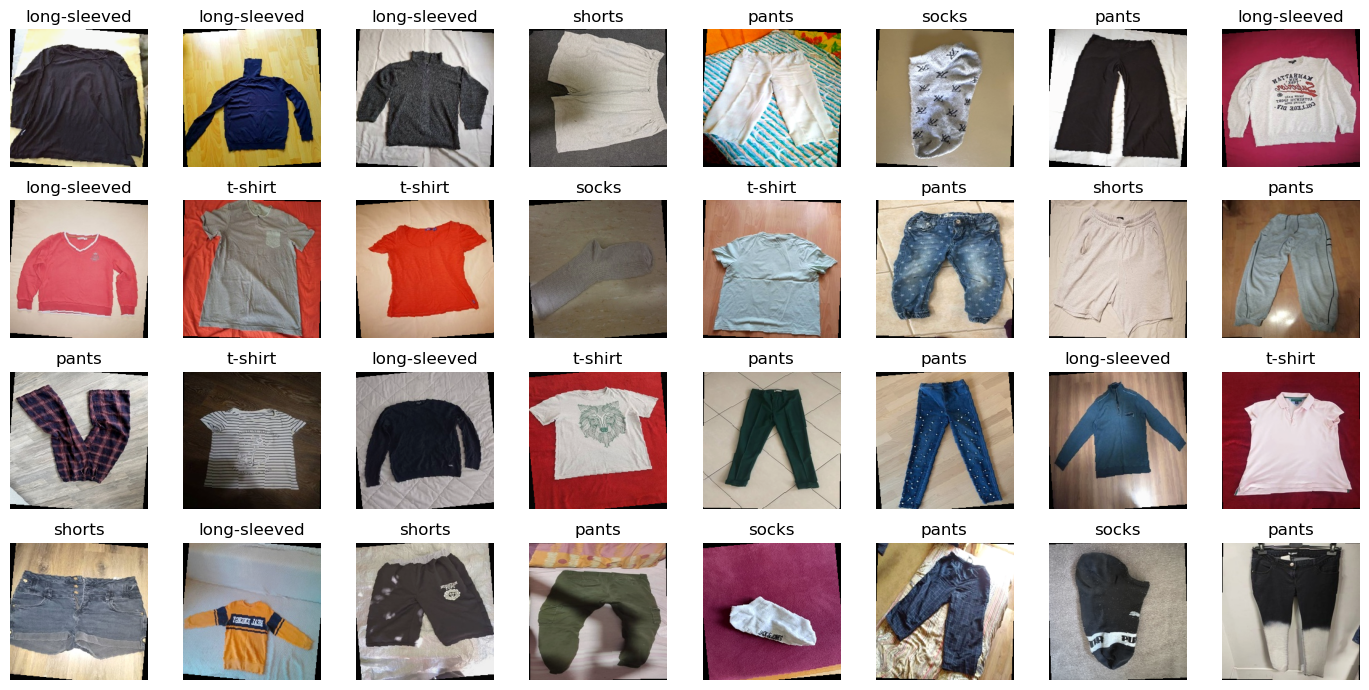

In [6]:
# Erklärung: Definiert eine Funktion, um normalisierte Bilder wieder visuell darstellbar zu machen.
def denormalize(img):
    # Erklärung: Kopiert das Bild auf die CPU, ohne den Originaltensor zu verändern.
    x = img.detach().cpu().clone()
    # Erklärung: Formt Mean so um, dass es auf alle Bildkanäle angewendet werden kann.
    mean_t = torch.tensor(mean).view(3, 1, 1)
    # Erklärung: Formt Std so um, dass es auf alle Bildkanäle angewendet werden kann.
    std_t = torch.tensor(std).view(3, 1, 1)
    # Erklärung: Formt Mean so um, dass es auf alle Bildkanäle angewendet werden kann.
    x = x * std_t + mean_t
    # Erklärung: Ändert die Dimensionen von Channel-First zu Height-Width-Channel für Matplotlib.
    return x.clamp(0, 1).permute(1, 2, 0).numpy()

# Erklärung: Nimmt einen Beispielbatch aus dem DataLoader.
images, labels = next(iter(train_loader))
# Erklärung: Erstellt eine Matplotlib-Figur mit mehreren Achsen.
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
# Erklärung: Geht durch Achsen, Bilder und Labels, um jedes Bild einzeln zu plotten.
for ax, img, label in zip(axes.ravel(), images[:32], labels[:32]):
    # Erklärung: Zeigt ein Bild in der jeweiligen Achse an.
    ax.imshow(denormalize(img))
    # Erklärung: Schreibt die echte Klasse als Titel über das Bild.
    ax.set_title(train_dataset.classes[label.item()])
    # Erklärung: Blendet Achsen aus, damit nur das Bild sichtbar ist.
    ax.axis("off")
# Erklärung: Optimiert Abstände zwischen Subplots.
plt.tight_layout()
# Erklärung: Zeigt die Figur im Notebook an.
plt.show()


## 7. Modellarchitektur

Ab hier wird das CNN definiert.

## Model Architecture

The model is trained from scratch and stays below the assignment limit of 800,000 trainable parameters.


## 8. Architektur im Detail

Diese Zelle definiert alle Bausteine des finalen CNN: ConvBNAct, InvertedResidualBlock und ClothingCNNFinal.

In [7]:
# Erklärung: Definiert einen Standardblock: Convolution, BatchNorm und Aktivierung.
class ConvBNAct(nn.Sequential):
    # Erklärung: Konstruktor: legt fest, wie dieser Block oder dieses Modell aufgebaut wird.
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, groups=1):
        # Erklärung: Berechnet Padding, damit 3x3-Convolutions bei stride=1 die Größe ungefähr behalten.
        padding = kernel_size // 2
        # Erklärung: Initialisiert die Elternklasse von PyTorch korrekt.
        super().__init__(
            # Erklärung: Erzeugt eine Convolution-Schicht, die Feature Maps extrahiert oder Kanäle mischt.
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False),
            # Erklärung: Normalisiert Feature Maps und stabilisiert das Training.
            nn.BatchNorm2d(out_channels),
            # Erklärung: SiLU-Aktivierung fügt Nichtlinearität hinzu.
            nn.SiLU(inplace=True),
        )


# Erklärung: Definiert den effizienten Hauptblock des CNN.
class InvertedResidualBlock(nn.Module):
    # Erklärung: Konstruktor: legt fest, wie dieser Block oder dieses Modell aufgebaut wird.
    def __init__(self, in_channels, out_channels, stride=1, expansion=3, dropout=0.0):
        # Erklärung: Initialisiert die Elternklasse von PyTorch korrekt.
        super().__init__()
        # Erklärung: Berechnet die temporär erweiterten Kanäle im Block.
        hidden_channels = in_channels * expansion
        # Erklärung: Entscheidet, ob eine Residual-Verbindung möglich ist.
        self.use_residual = stride == 1 and in_channels == out_channels

        # Erklärung: Speichert die Hauptschichten des Blocks als Sequenz.
        self.block = nn.Sequential(
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            ConvBNAct(in_channels, hidden_channels, kernel_size=1),
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            ConvBNAct(hidden_channels, hidden_channels, kernel_size=3, stride=stride, groups=hidden_channels),
            # Erklärung: Erzeugt eine Convolution-Schicht, die Feature Maps extrahiert oder Kanäle mischt.
            nn.Conv2d(hidden_channels, out_channels, kernel_size=1, bias=False),
            # Erklärung: Normalisiert Feature Maps und stabilisiert das Training.
            nn.BatchNorm2d(out_channels),
        )
        # Erklärung: SiLU-Aktivierung fügt Nichtlinearität hinzu.
        self.activation = nn.SiLU(inplace=True)
        # Erklärung: Dropout reduziert Overfitting, indem während Training zufällig Features deaktiviert werden.
        self.dropout = nn.Dropout2d(p=dropout) if dropout > 0 else nn.Identity()

    # Erklärung: Forward beschreibt, wie Daten durch den Block oder das Modell fließen.
    def forward(self, x):
        # Erklärung: Gibt die Eingabe durch den Hauptblock.
        out = self.block(x)
        # Erklärung: Entscheidet, ob eine Residual-Verbindung möglich ist.
        if self.use_residual:
            # Erklärung: Addiert die ursprüngliche Eingabe als Residual-Verbindung.
            out = out + x
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        out = self.activation(out)
        # Erklärung: Gibt die Ausgabe nach optionalem Dropout zurück.
        return self.dropout(out)


# Erklärung: Definiert das finale CNN für die 5 Kleidungsklassen.
class ClothingCNNFinal(nn.Module):
    # Erklärung: Konstruktor: legt fest, wie dieser Block oder dieses Modell aufgebaut wird.
    def __init__(self, num_classes=5):
        # Erklärung: Initialisiert die Elternklasse von PyTorch korrekt.
        super().__init__()
        # Erklärung: Erste Convolution: wandelt RGB-Bild in 32 Feature Maps um und reduziert die Auflösung.
        self.stem = ConvBNAct(3, 32, kernel_size=3, stride=2)
        # Erklärung: Sequenz der Feature-Extractor-Blöcke.
        self.features = nn.Sequential(
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(32, 48, stride=1, expansion=3, dropout=0.02),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(48, 64, stride=2, expansion=3, dropout=0.03),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(64, 64, stride=1, expansion=3, dropout=0.03),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(64, 96, stride=2, expansion=3, dropout=0.04),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(96, 96, stride=1, expansion=3, dropout=0.04),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(96, 128, stride=2, expansion=3, dropout=0.05),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(128, 128, stride=1, expansion=3, dropout=0.05),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(128, 144, stride=1, expansion=3, dropout=0.06),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(144, 176, stride=2, expansion=3, dropout=0.07),
            # Erklärung: Fügt einen effizienten Inverted-Residual-Block mit bestimmten Kanälen hinzu.
            InvertedResidualBlock(176, 192, stride=1, expansion=3, dropout=0.07),
        )
        # Erklärung: Global Average Pooling reduziert jede Feature Map auf einen Wert.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        # Erklärung: Classifier wandelt Features in Klassenscores um.
        self.classifier = nn.Sequential(
            # Erklärung: Macht aus [batch, channels, 1, 1] einen Vektor [batch, channels].
            nn.Flatten(),
            # Erklärung: Dropout reduziert Overfitting, indem während Training zufällig Features deaktiviert werden.
            nn.Dropout(0.35),
            # Erklärung: Lineare Schicht kombiniert Features und erzeugt neue Werte oder Klassenscores.
            nn.Linear(192, 96),
            # Erklärung: SiLU-Aktivierung fügt Nichtlinearität hinzu.
            nn.SiLU(inplace=True),
            # Erklärung: Dropout reduziert Overfitting, indem während Training zufällig Features deaktiviert werden.
            nn.Dropout(0.25),
            # Erklärung: Lineare Schicht kombiniert Features und erzeugt neue Werte oder Klassenscores.
            nn.Linear(96, num_classes),
        )

    # Erklärung: Forward beschreibt, wie Daten durch den Block oder das Modell fließen.
    def forward(self, x):
        # Erklärung: Leitet die Eingabe zuerst durch die Stem-Schicht.
        x = self.stem(x)
        # Erklärung: Extrahiert tieferliegende Merkmale mit den Feature-Blöcken.
        x = self.features(x)
        # Erklärung: Fasst räumliche Information global zusammen.
        x = self.pool(x)
        # Erklärung: Gibt die finalen 5 Logits zurück.
        return self.classifier(x)


# Erklärung: Hilfsfunktion zur Anzahl der trainierbaren Parameter.
def count_parameters(model):
    # Erklärung: Zählt nur Parameter, die wirklich trainiert werden.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Erklärung: Erstellt das Modell und verschiebt es auf GPU oder CPU.
model = ClothingCNNFinal(num_classes=num_classes).to(device)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print(model)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Trainable parameters:", count_parameters(model))
# Erklärung: Prüft sofort, ob der erwartete Pfad existiert; sonst stoppt das Notebook mit Fehlermeldung.
assert count_parameters(model) <= 800_000


ClothingCNNFinal(
  (stem): ConvBNAct(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (features): Sequential(
    (0): InvertedResidualBlock(
      (block): Sequential(
        (0): ConvBNAct(
          (0): Conv2d(32, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): ConvBNAct(
          (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96, bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (2): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

## 9. Loss, Training pro Epoche und Evaluation

Diese Zelle enthält die Funktionen, mit denen das Modell trainiert und bewertet wird.

In [8]:
# Erklärung: Definiert die Loss-Funktion für Mehrklassenklassifikation.
criterion = nn.CrossEntropyLoss()


# Erklärung: Trainiert das Modell genau eine Epoche.
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    # Erklärung: Aktiviert Trainingsmodus, wichtig für Dropout und BatchNorm.
    model.train()
    # Erklärung: Initialisiert Zähler für Loss und Accuracy.
    running_loss = 0.0
    # Erklärung: Initialisiert Zähler für Loss und Accuracy.
    correct = 0
    # Erklärung: Initialisiert Zähler für Loss und Accuracy.
    total = 0

    # Erklärung: Iteriert batchweise über Bilder und Labels.
    for images, labels in loader:
        # Erklärung: Verschiebt Tensoren auf GPU oder CPU.
        images = images.to(device, non_blocking=True)
        # Erklärung: Verschiebt Tensoren auf GPU oder CPU.
        labels = labels.to(device, non_blocking=True)
        # Erklärung: Setzt alte Gradienten zurück, bevor neue berechnet werden.
        optimizer.zero_grad(set_to_none=True)

        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        if USE_AMP:
            # Erklärung: Aktiviert Mixed Precision für schnellere GPU-Berechnung.
            with torch.amp.autocast(device_type="cuda"):
                # Erklärung: Forward Pass: Modell berechnet Scores für die Bilder.
                outputs = model(images)
                # Erklärung: Berechnet den Fehler zwischen Vorhersagen und echten Labels.
                loss = criterion(outputs, labels)
            # Erklärung: Berechnet Gradienten für alle trainierbaren Parameter.
            scaler.scale(loss).backward()
            # Erklärung: Aktualisiert die Modellgewichte.
            scaler.step(optimizer)
            # Erklärung: Aktualisiert den GradScaler für AMP.
            scaler.update()
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        else:
            # Erklärung: Forward Pass: Modell berechnet Scores für die Bilder.
            outputs = model(images)
            # Erklärung: Berechnet den Fehler zwischen Vorhersagen und echten Labels.
            loss = criterion(outputs, labels)
            # Erklärung: Berechnet Gradienten für alle trainierbaren Parameter.
            loss.backward()
            # Erklärung: Aktualisiert die Modellgewichte.
            optimizer.step()

        # Erklärung: Initialisiert Zähler für Loss und Accuracy.
        running_loss += loss.item() * images.size(0)
        # Erklärung: Initialisiert Zähler für Loss und Accuracy.
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        # Erklärung: Initialisiert Zähler für Loss und Accuracy.
        total += labels.size(0)

    # Erklärung: Gibt durchschnittlichen Loss und Accuracy zurück.
    return running_loss / total, correct / total


# Erklärung: Bewertet das Modell ohne Gewichtsupdate.
def evaluate(model, loader, criterion):
    # Erklärung: Schaltet in Evaluationsmodus; Dropout aus, BatchNorm stabil.
    model.eval()
    # Erklärung: Initialisiert Zähler für Loss und Accuracy.
    running_loss = 0.0
    # Erklärung: Initialisiert Zähler für Loss und Accuracy.
    correct = 0
    # Erklärung: Initialisiert Zähler für Loss und Accuracy.
    total = 0

    # Erklärung: Deaktiviert Gradienten, spart Speicher und Zeit bei Evaluation.
    with torch.no_grad():
        # Erklärung: Iteriert batchweise über Bilder und Labels.
        for images, labels in loader:
            # Erklärung: Verschiebt Tensoren auf GPU oder CPU.
            images = images.to(device, non_blocking=True)
            # Erklärung: Verschiebt Tensoren auf GPU oder CPU.
            labels = labels.to(device, non_blocking=True)

            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            if USE_AMP:
                # Erklärung: Aktiviert Mixed Precision für schnellere GPU-Berechnung.
                with torch.amp.autocast(device_type="cuda"):
                    # Erklärung: Forward Pass: Modell berechnet Scores für die Bilder.
                    outputs = model(images)
                    # Erklärung: Berechnet den Fehler zwischen Vorhersagen und echten Labels.
                    loss = criterion(outputs, labels)
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            else:
                # Erklärung: Forward Pass: Modell berechnet Scores für die Bilder.
                outputs = model(images)
                # Erklärung: Berechnet den Fehler zwischen Vorhersagen und echten Labels.
                loss = criterion(outputs, labels)

            # Erklärung: Initialisiert Zähler für Loss und Accuracy.
            running_loss += loss.item() * images.size(0)
            # Erklärung: Initialisiert Zähler für Loss und Accuracy.
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            # Erklärung: Initialisiert Zähler für Loss und Accuracy.
            total += labels.size(0)

    # Erklärung: Gibt durchschnittlichen Loss und Accuracy zurück.
    return running_loss / total, correct / total


## 10. WandB-Run starten

Diese Zelle speichert die Experiment-Konfiguration in WandB.

In [9]:
# Erklärung: Führt den folgenden Block nur aus, wenn WandB aktiviert ist.
if USE_WANDB:
    # Erklärung: Startet einen neuen WandB-Run.
    wandb.init(
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        entity=WANDB_ENTITY,
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        project=WANDB_PROJECT,
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        name=WANDB_RUN_NAME,
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        group=WANDB_GROUP,
        # Erklärung: Speichert Hyperparameter und Run-Informationen in WandB.
        config={
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "architecture": "ClothingCNNFinal",
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "parameters": count_parameters(model),
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "dataset": str(DATA_DIR),
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "image_size": IMAGE_SIZE,
            # Erklärung: Übergibt die Batchgröße an den DataLoader.
            "batch_size": BATCH_SIZE,
            # Erklärung: Erstellt den AdamW-Optimizer für Gewichtsupdates.
            "optimizer": "AdamW",
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "learning_rate": 0.001,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "weight_decay": 1e-4,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "loss": "CrossEntropyLoss",
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "weighted_sampler": True,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "augmentation": True,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "early_stopping": "validation_loss",
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "seed": SEED,
        },
    )


## 11. Trainingsschleife mit Early Stopping

Diese Zelle trainiert das Modell, speichert den besten Zustand und stoppt automatisch bei Stagnation.

In [10]:
# Erklärung: Maximale Anzahl an Trainingsepochen.
num_epochs = 70
# Erklärung: Anzahl Epochen ohne Verbesserung, bevor Early Stopping stoppt.
patience = 9
# Erklärung: Start-Lernrate des Optimizers.
learning_rate = 0.001
# Erklärung: Regularisierung gegen zu große Gewichte.
weight_decay = 1e-4

# Erklärung: Erstellt das Modell und verschiebt es auf GPU oder CPU.
model = ClothingCNNFinal(num_classes=num_classes).to(device)
# Erklärung: Erstellt den AdamW-Optimizer für Gewichtsupdates.
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
# Erklärung: Scheduler reduziert LR, wenn Validation Loss stagniert.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
# Erklärung: Skaliert Loss bei AMP, um numerische Probleme zu vermeiden.
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

# Erklärung: Speichert die beste bisher gesehene Validation Loss.
best_val_loss = float("inf")
# Erklärung: Speichert die Accuracy des besten Validation-Modells.
best_val_acc = 0.0
# Erklärung: Speichert die Gewichte des besten Modells.
best_model_state = None
# Erklärung: Zählt Epochen ohne Verbesserung für Early Stopping.
epochs_without_improvement = 0
# Erklärung: Sammelt Werte für spätere Trainingskurven.
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

# Erklärung: Maximale Anzahl an Trainingsepochen.
for epoch in range(1, num_epochs + 1):
    # Erklärung: Trainiert eine Epoche und erhält Train Loss/Accuracy.
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    # Erklärung: Berechnet Validation Loss/Accuracy nach der Epoche.
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    # Erklärung: Liest die aktuelle Learning Rate aus dem Optimizer.
    current_lr = optimizer.param_groups[0]["lr"]
    # Erklärung: Informiert den Scheduler über die aktuelle Validation Loss.
    scheduler.step(val_loss)

    # Erklärung: Sammelt Werte für spätere Trainingskurven.
    history["train_loss"].append(train_loss)
    # Erklärung: Sammelt Werte für spätere Trainingskurven.
    history["train_acc"].append(train_acc)
    # Erklärung: Sammelt Werte für spätere Trainingskurven.
    history["val_loss"].append(val_loss)
    # Erklärung: Sammelt Werte für spätere Trainingskurven.
    history["val_acc"].append(val_acc)
    # Erklärung: Sammelt Werte für spätere Trainingskurven.
    history["lr"].append(current_lr)

    # Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
    print(
        # Erklärung: Maximale Anzahl an Trainingsepochen.
        f"Epoch {epoch:02d}/{num_epochs} | "
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        # Erklärung: Liest die aktuelle Learning Rate aus dem Optimizer.
        f"LR: {current_lr:.7f}"
    )

    # Erklärung: Führt den folgenden Block nur aus, wenn WandB aktiviert ist.
    if USE_WANDB:
        # Erklärung: Loggt Metriken oder Artefakte in WandB.
        wandb.log({
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "epoch": epoch,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "train_loss": train_loss,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "train_acc": train_acc,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "val_loss": val_loss,
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            "val_acc": val_acc,
            # Erklärung: Liest die aktuelle Learning Rate aus dem Optimizer.
            "lr": current_lr,
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        })

    # Erklärung: Speichert die beste bisher gesehene Validation Loss.
    if val_loss < best_val_loss:
        # Erklärung: Speichert die beste bisher gesehene Validation Loss.
        best_val_loss = val_loss
        # Erklärung: Speichert die Accuracy des besten Validation-Modells.
        best_val_acc = val_acc
        # Erklärung: Speichert die Gewichte des besten Modells.
        best_model_state = copy.deepcopy(model.state_dict())
        # Erklärung: Speichert die Gewichte des besten Modells.
        torch.save(
            {
                "model_state_dict": best_model_state,
                "class_names": classes,
                "mean": mean,
                "std": std,
                "image_size": IMAGE_SIZE,
                "epoch": epoch,
                "val_loss": best_val_loss,
                "val_accuracy": best_val_acc,
            },
            BEST_MODEL_PATH,
        )
        # Erklärung: Zählt Epochen ohne Verbesserung für Early Stopping.
        epochs_without_improvement = 0
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    else:
        # Erklärung: Zählt Epochen ohne Verbesserung für Early Stopping.
        epochs_without_improvement += 1

    # Erklärung: Zählt Epochen ohne Verbesserung für Early Stopping.
    if epochs_without_improvement >= patience:
        # Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
        print("Early stopping triggered.")
        # Erklärung: Bricht die Trainingsschleife ab.
        break

# Erklärung: Speichert die Gewichte des besten Modells.
model.load_state_dict(best_model_state)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Best validation loss:", best_val_loss)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Best validation accuracy:", best_val_acc)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Best model saved to:", BEST_MODEL_PATH)

# Erklärung: Führt den folgenden Block nur aus, wenn WandB aktiviert ist.
if USE_WANDB:
    # Erklärung: Speichert die beste bisher gesehene Validation Loss.
    wandb.log({"best_val_loss": best_val_loss, "best_val_acc": best_val_acc})


Epoch 01/70 | Train Loss: 1.5732 | Train Acc: 0.2613 | Val Loss: 1.5545 | Val Acc: 0.3325 | LR: 0.0010000
Epoch 02/70 | Train Loss: 1.3606 | Train Acc: 0.4153 | Val Loss: 1.2695 | Val Acc: 0.5267 | LR: 0.0010000
Epoch 03/70 | Train Loss: 1.0703 | Train Acc: 0.5814 | Val Loss: 1.0819 | Val Acc: 0.6165 | LR: 0.0010000
Epoch 04/70 | Train Loss: 0.7661 | Train Acc: 0.7252 | Val Loss: 0.5403 | Val Acc: 0.7961 | LR: 0.0010000
Epoch 05/70 | Train Loss: 0.5548 | Train Acc: 0.7984 | Val Loss: 0.4462 | Val Acc: 0.8350 | LR: 0.0010000
Epoch 06/70 | Train Loss: 0.4840 | Train Acc: 0.8301 | Val Loss: 0.3497 | Val Acc: 0.8811 | LR: 0.0010000
Epoch 07/70 | Train Loss: 0.4162 | Train Acc: 0.8598 | Val Loss: 0.4021 | Val Acc: 0.8665 | LR: 0.0010000
Epoch 08/70 | Train Loss: 0.3981 | Train Acc: 0.8604 | Val Loss: 0.3469 | Val Acc: 0.8835 | LR: 0.0010000
Epoch 09/70 | Train Loss: 0.3396 | Train Acc: 0.8833 | Val Loss: 0.2852 | Val Acc: 0.8932 | LR: 0.0010000
Epoch 10/70 | Train Loss: 0.2999 | Train Acc: 

## 12. Trainingskurven plotten

Diese Zelle zeigt Loss und Accuracy über die Epochen.

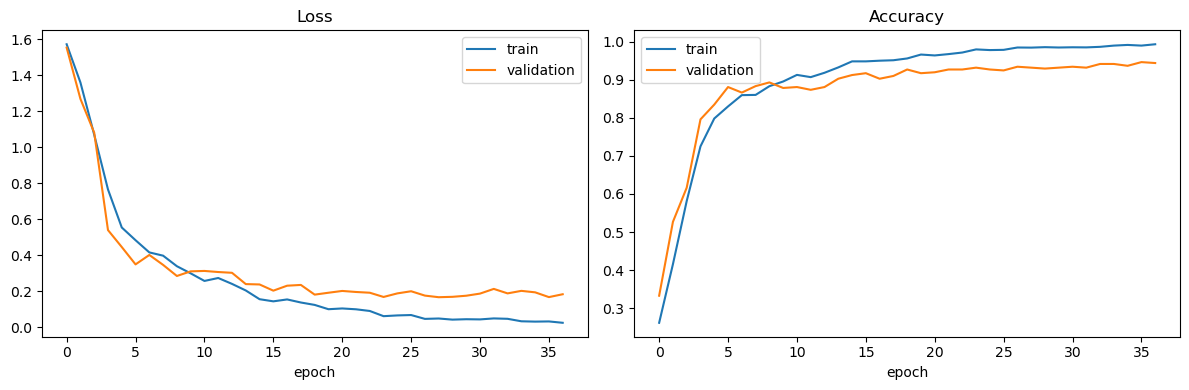

In [11]:
# Erklärung: Erstellt eine Matplotlib-Figur mit mehreren Achsen.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Erklärung: Zeichnet eine Kurve in den Plot.
axes[0].plot(history["train_loss"], label="train")
# Erklärung: Zeichnet eine Kurve in den Plot.
axes[0].plot(history["val_loss"], label="validation")
# Erklärung: Schreibt die echte Klasse als Titel über das Bild.
axes[0].set_title("Loss")
# Erklärung: Beschriftet die x-Achse.
axes[0].set_xlabel("epoch")
# Erklärung: Zeigt die Legende für Train/Validation an.
axes[0].legend()

# Erklärung: Zeichnet eine Kurve in den Plot.
axes[1].plot(history["train_acc"], label="train")
# Erklärung: Zeichnet eine Kurve in den Plot.
axes[1].plot(history["val_acc"], label="validation")
# Erklärung: Schreibt die echte Klasse als Titel über das Bild.
axes[1].set_title("Accuracy")
# Erklärung: Beschriftet die x-Achse.
axes[1].set_xlabel("epoch")
# Erklärung: Zeigt die Legende für Train/Validation an.
axes[1].legend()

# Erklärung: Optimiert Abstände zwischen Subplots.
plt.tight_layout()
# Erklärung: Zeigt die Figur im Notebook an.
plt.show()


## 13. Testevaluation, Classification Report und Confusion Matrix

Diese Zelle lädt das beste Modell und bewertet es auf dem Testset.

Test accuracy: 0.9232673267326733
              precision    recall  f1-score   support

long-sleeved     0.9848    0.9286    0.9559        70
       pants     0.9043    0.9444    0.9239        90
      shorts     0.8846    0.8070    0.8440        57
       socks     0.9091    0.9091    0.9091        77
     t-shirt     0.9304    0.9727    0.9511       110

    accuracy                         0.9233       404
   macro avg     0.9226    0.9124    0.9168       404
weighted avg     0.9235    0.9233    0.9228       404



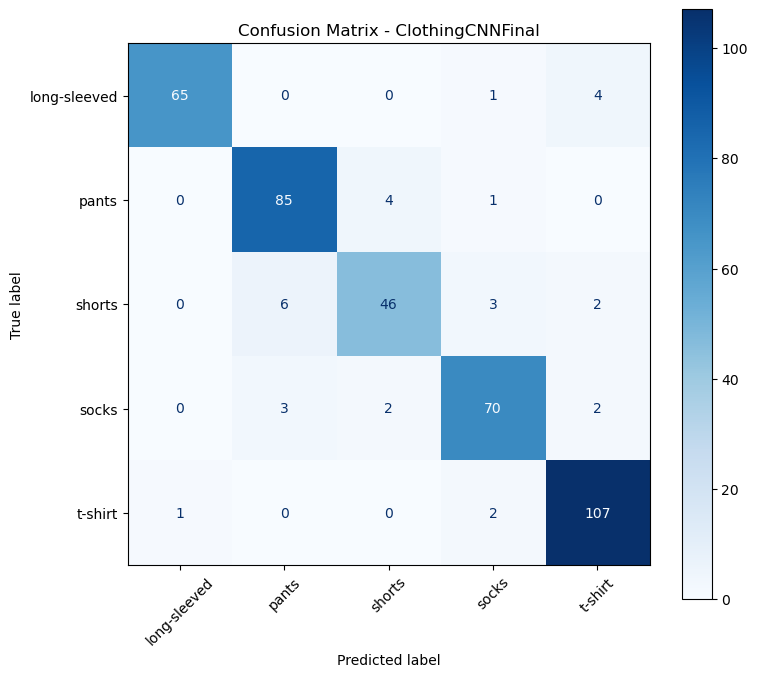

In [12]:
# Erklärung: Importiert Metriken für Accuracy, Report und Confusion Matrix.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Erklärung: Lädt gespeicherte Modellgewichte in das Modell.
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint.get("model_state_dict", checkpoint))
# Erklärung: Verschiebt Tensoren auf GPU oder CPU.
model.to(device)
# Erklärung: Schaltet in Evaluationsmodus; Dropout aus, BatchNorm stabil.
model.eval()

# Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
y_true = []
# Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
y_pred = []
# Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
misclassified = []
# Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
sample_offset = 0

# Erklärung: Deaktiviert Gradienten, spart Speicher und Zeit bei Evaluation.
with torch.no_grad():
    # Erklärung: Iteriert batchweise über Bilder und Labels.
    for images, labels in test_loader:
        # Erklärung: Verschiebt Tensoren auf GPU oder CPU.
        images = images.to(device, non_blocking=True)
        # Erklärung: Verschiebt Tensoren auf GPU oder CPU.
        labels = labels.to(device, non_blocking=True)

        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        if USE_AMP:
            # Erklärung: Aktiviert Mixed Precision für schnellere GPU-Berechnung.
            with torch.amp.autocast(device_type="cuda"):
                # Erklärung: Forward Pass: Modell berechnet Scores für die Bilder.
                outputs = model(images)
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        else:
            # Erklärung: Forward Pass: Modell berechnet Scores für die Bilder.
            outputs = model(images)

        # Erklärung: Wandelt Logits in Wahrscheinlichkeiten um.
        probs = torch.softmax(outputs, dim=1)
        # Erklärung: Wählt die Klasse mit dem höchsten Score als Vorhersage.
        preds = outputs.argmax(dim=1)
        # Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
        y_true.extend(labels.cpu().numpy())
        # Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
        y_pred.extend(preds.cpu().numpy())

        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        batch_paths = [test_dataset.samples[sample_offset + i][0] for i in range(labels.size(0))]
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        sample_offset += labels.size(0)

        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        for img, path, label, pred, prob_vector in zip(images.cpu(), batch_paths, labels.cpu(), preds.cpu(), probs.cpu()):
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            if label.item() != pred.item():
                # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
                confidence = prob_vector[pred.item()].item()
                # Erklärung: Bestimmt die Top-3-Vorhersagen für Analyse.
                top3 = torch.topk(prob_vector, k=3)
                # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
                top3_text = ", ".join(
                    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
                    f"{test_dataset.classes[idx]}:{score:.3f}"
                    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
                    for score, idx in zip(top3.values.tolist(), top3.indices.tolist())
                )
                # Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
                misclassified.append((img, path, label.item(), pred.item(), confidence, top3_text))

# Erklärung: Berechnet die finale Test Accuracy.
test_acc = accuracy_score(y_true, y_pred)
# Erklärung: Berechnet Precision, Recall und F1 pro Klasse.
report_dict = classification_report(y_true, y_pred, target_names=test_dataset.classes, digits=4, output_dict=True)
# Erklärung: Berechnet Precision, Recall und F1 pro Klasse.
report_text = classification_report(y_true, y_pred, target_names=test_dataset.classes, digits=4)

# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Test accuracy:", test_acc)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print(report_text)

# Erklärung: Berechnet die Confusion Matrix.
cm = confusion_matrix(y_true, y_pred)
# Erklärung: Berechnet die Confusion Matrix.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
# Erklärung: Erstellt eine Matplotlib-Figur mit mehreren Achsen.
fig, ax = plt.subplots(figsize=(8, 7))
# Erklärung: Zeichnet eine Kurve in den Plot.
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
# Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
plt.title("Confusion Matrix - ClothingCNNFinal")
# Erklärung: Optimiert Abstände zwischen Subplots.
plt.tight_layout()
# Erklärung: Zeigt die Figur im Notebook an.
plt.show()


## 14. Fehlklassifizierte Bilder anzeigen

Diese Zelle zeigt Beispiele, bei denen das Modell falsch vorhergesagt hat.

Misclassified test images: 31


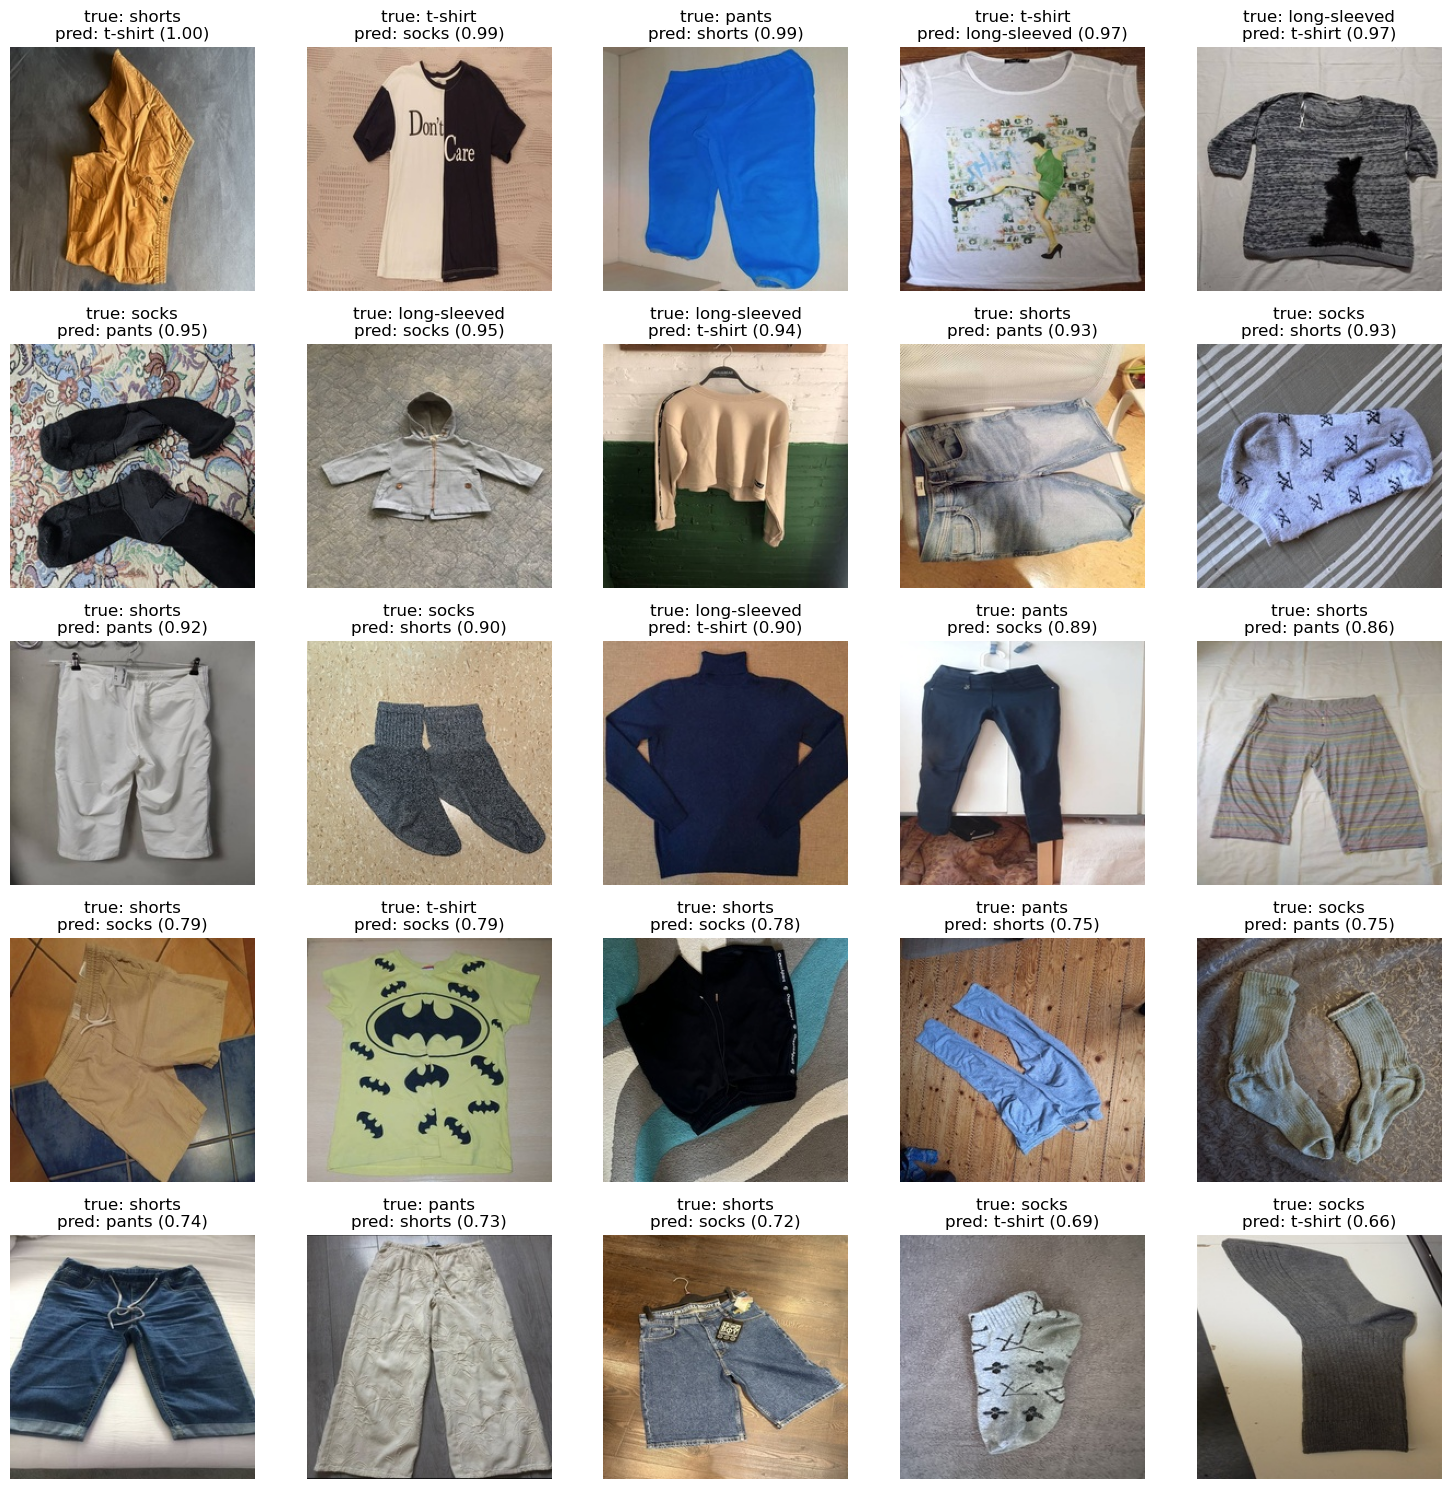

In [13]:
# Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
misclassified_sorted = sorted(misclassified, key=lambda x: x[4], reverse=True)
# Erklärung: Gibt eine Kontrollinformation aus, damit wir sehen, ob die Zelle korrekt läuft.
print("Misclassified test images:", len(misclassified_sorted))

# Erklärung: Sortiert Fehler nach Confidence, damit sichere Fehler zuerst erscheinen.
n = min(25, len(misclassified_sorted))
# Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
if n > 0:
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    cols = 5
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    rows = (n + cols - 1) // cols
    # Erklärung: Erstellt eine Matplotlib-Figur mit mehreren Achsen.
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    axes = np.array(axes).reshape(-1)

    # Erklärung: Geht durch Achsen, Bilder und Labels, um jedes Bild einzeln zu plotten.
    for ax, (img, path, true_idx, pred_idx, confidence, top3_text) in zip(axes, misclassified_sorted[:n]):
        # Erklärung: Zeigt ein Bild in der jeweiligen Achse an.
        ax.imshow(denormalize(img))
        # Erklärung: Schreibt die echte Klasse als Titel über das Bild.
        ax.set_title(
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            f"true: {test_dataset.classes[true_idx]}\n"
            # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
            f"pred: {test_dataset.classes[pred_idx]} ({confidence:.2f})"
        )
        # Erklärung: Blendet Achsen aus, damit nur das Bild sichtbar ist.
        ax.axis("off")

    # Erklärung: Geht durch Achsen, Bilder und Labels, um jedes Bild einzeln zu plotten.
    for ax in axes[n:]:
        # Erklärung: Blendet Achsen aus, damit nur das Bild sichtbar ist.
        ax.axis("off")

    # Erklärung: Optimiert Abstände zwischen Subplots.
    plt.tight_layout()
    # Erklärung: Zeigt die Figur im Notebook an.
    plt.show()


## 15. Finale Ergebnisse in WandB speichern

Diese Zelle loggt Metriken, Confusion Matrix und Fehlklassifikationen in WandB.

In [14]:
# Erklärung: Führt den folgenden Block nur aus, wenn WandB aktiviert ist.
if USE_WANDB:
    # Erklärung: Erstellt eine WandB-Tabelle für strukturierte Ergebnisse.
    class_metrics_table = wandb.Table(columns=["class", "precision", "recall", "f1_score", "support"])
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    for class_name in test_dataset.classes:
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        values = report_dict[class_name]
        # Erklärung: Fügt eine Zeile zur WandB-Tabelle hinzu.
        class_metrics_table.add_data(class_name, values["precision"], values["recall"], values["f1-score"], values["support"])

    # Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
    misclassified_table = wandb.Table(columns=["image", "path", "true_class", "predicted_class", "confidence", "top3"])
    # Erklärung: Sortiert Fehler nach Confidence, damit sichere Fehler zuerst erscheinen.
    for img, path, true_idx, pred_idx, confidence, top3_text in misclassified_sorted[:40]:
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        true_class = test_dataset.classes[true_idx]
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        pred_class = test_dataset.classes[pred_idx]
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        caption = f"true: {true_class} | pred: {pred_class} | conf: {confidence:.3f}"
        # Erklärung: Initialisiert Listen für echte Labels, Vorhersagen und Fehlerbeispiele.
        misclassified_table.add_data(wandb.Image(denormalize(img), caption=caption), str(path), true_class, pred_class, confidence, top3_text)

    # Erklärung: Loggt Metriken oder Artefakte in WandB.
    wandb.log({
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test_accuracy": test_acc,
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/class_metrics": class_metrics_table,
        # Erklärung: Zeichnet eine Kurve in den Plot.
        "test/confusion_matrix": wandb.plot.confusion_matrix(y_true=y_true, preds=y_pred, class_names=test_dataset.classes),
        # Erklärung: Berechnet die Confusion Matrix.
        "test/confusion_matrix_image": wandb.Image(fig),
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/misclassified_examples": misclassified_table,
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/misclassified_count": len(misclassified),
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/precision_macro": report_dict["macro avg"]["precision"],
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/recall_macro": report_dict["macro avg"]["recall"],
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/f1_macro": report_dict["macro avg"]["f1-score"],
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/precision_weighted": report_dict["weighted avg"]["precision"],
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/recall_weighted": report_dict["weighted avg"]["recall"],
        # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
        "test/f1_weighted": report_dict["weighted avg"]["f1-score"],
    # Erklärung: Erklärt bzw. führt den nächsten Python-Schritt in diesem Block aus.
    })
    # Erklärung: Beendet den WandB-Run sauber.
    model_artifact = wandb.Artifact(
        "best-clothing-cnn", type="model",
        metadata={"test_accuracy": test_acc, "classes": test_dataset.classes},
    )
    model_artifact.add_file(str(BEST_MODEL_PATH))
    wandb.log_artifact(model_artifact)
    wandb.finish()


best_val_acc,▁
best_val_loss,▁
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,█████████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▁▁▁▁▁
test/f1_macro,▁
test/f1_weighted,▁
test/misclassified_count,▁
test/precision_macro,▁
test/precision_weighted,▁
test/recall_macro,▁
+6,...
